<a href="https://colab.research.google.com/github/VedantPaste1705/CSL701_CS40_Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [11]:
# TASK 1: Environment Setup and Dataset Acquisition

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# Load dataset
# In Google Colab, upload the CSV file
from google.colab import files

uploaded = files.upload()

# Get uploaded file name
file_name = list(uploaded.keys())[0]

# Read dataset
df = pd.read_csv(file_name)

# Display first 5 rows
print("First 5 rows:")
print(df.head())

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display dataset information
print("\nDataset Information:")
df.info()

# Display statistical summary
print("\nStatistical Summary:")
print(df.describe())

Saving diabetes.csv to diabetes (1).csv
First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape:
(768, 9)

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries,

## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Counts:
Non-Diabetic (0): 500
Diabetic (1): 268

Class Percentages:
Non-Diabetic (0): 65.1 %
Diabetic (1): 34.9 %


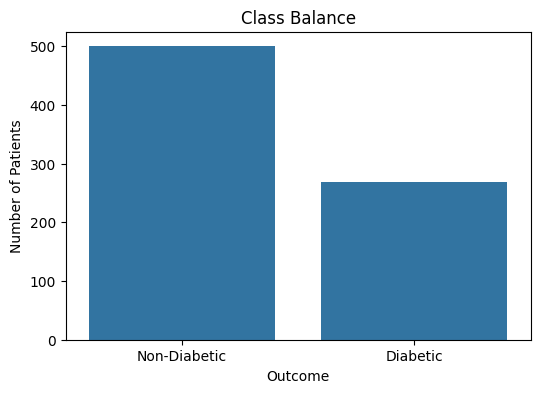

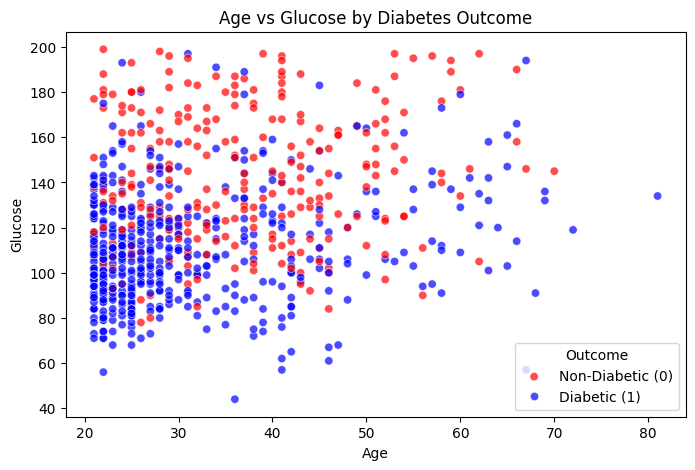


Explanation:
A simple linear decision boundary is insufficient because
diabetic and non-diabetic samples overlap in Age and Glucose.
Therefore, a single straight line cannot clearly separate
the two classes.


In [12]:
# TASK 2: Exploratory Data Analysis (EDA)

# --------------------------------------------------
# 1. Calculate class count and percentage
# --------------------------------------------------

outcome_counts = df["Outcome"].value_counts().sort_index()

outcome_percentages = (
    df["Outcome"].value_counts(normalize=True).sort_index() * 100
)

print("Class Counts:")
print("Non-Diabetic (0):", outcome_counts[0])
print("Diabetic (1):", outcome_counts[1])

print("\nClass Percentages:")
print("Non-Diabetic (0):", round(outcome_percentages[0], 2), "%")
print("Diabetic (1):", round(outcome_percentages[1], 2), "%")


# --------------------------------------------------
# 2. Bar Chart - Class Balance
# --------------------------------------------------

plt.figure(figsize=(6, 4))

sns.barplot(
    x=["Non-Diabetic", "Diabetic"],
    y=[outcome_counts[0], outcome_counts[1]]
)

plt.title("Class Balance")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.show()


# --------------------------------------------------
# 3. Scatter Plot - Age vs Glucose
# --------------------------------------------------

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Glucose",
    hue="Outcome",
    palette={0: "blue", 1: "red"},
    alpha=0.7
)

plt.title("Age vs Glucose by Diabetes Outcome")
plt.xlabel("Age")
plt.ylabel("Glucose")
plt.legend(
    title="Outcome",
    labels=["Non-Diabetic (0)", "Diabetic (1)"]
)

plt.show()


# --------------------------------------------------
# 4. Explanation
# --------------------------------------------------

print("\nExplanation:")
print("A simple linear decision boundary is insufficient because")
print("diabetic and non-diabetic samples overlap in Age and Glucose.")
print("Therefore, a single straight line cannot clearly separate")
print("the two classes.")

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [13]:
# TASK 3: Preprocessing and Handling Missing Values

# Features where zero is physically impossible
zero_invalid_features = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Display number of zero values before handling
print("Zero values before preprocessing:\n")

for column in zero_invalid_features:
    print(column, ":", (df[column] == 0).sum())

# Replace zero values with NaN
df[zero_invalid_features] = df[zero_invalid_features].replace(0, np.nan)

# Display missing values
print("\nMissing values after replacing zeros:\n")
print(df.isnull().sum())

# Drop rows containing missing values
df = df.dropna()

# Reset index
df = df.reset_index(drop=True)

# Verify missing values
print("\nMissing values after cleaning:\n")
print(df.isnull().sum())

print("\nDataset shape after preprocessing:")
print(df.shape)

Zero values before preprocessing:

Glucose : 0
BloodPressure : 0
SkinThickness : 0
Insulin : 0
BMI : 0

Missing values after replacing zeros:

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Missing values after cleaning:

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Dataset shape after preprocessing:
(768, 9)


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [14]:
# TASK 4: Stratified Train-Test Splitting

# Feature matrix X = first 8 columns
X = df.iloc[:, 0:8]

# Target vector y = 9th column
y = df.iloc[:, 8]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

# Split data into 80% training and 20% testing
# stratify=y preserves class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data shape:")
print(X_train.shape)

print("Testing data shape:")
print(X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Features (X):
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Target (y):
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

Training data shape:
(614, 8)
Testing data shape:
(154, 8)

Training class distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

Testing class distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [15]:
# TASK 5: Custom Bootstrap Sampling Function

def get_bootstrap_sample(X, y):
    # Number of training samples
    n = len(X)

    # Random indices with replacement
    indices = np.random.choice(
        np.arange(n),
        size=n,
        replace=True
    )

    # Create bootstrap samples
    X_bootstrap = X.iloc[indices].reset_index(drop=True)
    y_bootstrap = y.iloc[indices].reset_index(drop=True)

    return X_bootstrap, y_bootstrap, indices


# Generate one bootstrap sample
X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
    X_train,
    y_train
)

print("Original training size:", len(X_train))
print("Bootstrap sample size:", len(X_bootstrap))

# Find duplicate indices
unique_indices, counts = np.unique(
    bootstrap_indices,
    return_counts=True
)

duplicate_indices = unique_indices[counts > 1]

# Find OOB indices
all_indices = set(range(len(X_train)))
selected_indices = set(bootstrap_indices)

oob_indices = sorted(all_indices - selected_indices)

print("\nNumber of unique samples selected:",
      len(unique_indices))

print("Number of duplicate indices:",
      len(duplicate_indices))

print("Duplicate indices:")
print(duplicate_indices)

print("\nNumber of OOB samples:",
      len(oob_indices))

print("OOB indices:")
print(oob_indices)

Original training size: 614
Bootstrap sample size: 614

Number of unique samples selected: 389
Number of duplicate indices: 160
Duplicate indices:
[ 14  15  16  17  23  24  31  33  41  45  48  49  50  59  65  69  70  71
  72  74  79  82  86  88  89  91  95 104 105 116 122 124 125 130 133 138
 144 151 153 156 157 160 162 163 165 168 181 183 184 185 188 192 193 199
 202 213 215 220 222 226 229 237 238 244 247 250 252 254 256 264 271 278
 281 284 287 289 290 292 293 295 296 303 304 306 308 309 313 316 320 322
 323 330 334 339 341 342 349 350 358 367 370 384 389 390 391 393 395 398
 399 413 417 418 420 425 429 431 433 436 437 439 442 449 459 462 468 471
 472 473 477 479 486 488 489 495 504 509 512 513 517 528 533 537 538 541
 544 555 556 562 565 566 567 568 585 586 589 595 597 599 606 613]

Number of OOB samples: 225
OOB indices:
[1, 3, 4, 5, 6, 7, 8, 9, 11, 18, 25, 26, 29, 30, 32, 34, 36, 42, 51, 56, 57, 58, 64, 67, 68, 73, 76, 77, 78, 80, 81, 85, 87, 90, 93, 94, 96, 102, 103, 108, 109, 1

#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [16]:
# TASK 6: Growing the Ensemble of Base Classifiers

# Number of bootstrap iterations
B = 50

# Empty list for storing decision trees
ensemble = []

# Train 50 decision trees
for i in range(B):

    # Generate bootstrap sample
    X_bootstrap, y_bootstrap, indices = get_bootstrap_sample(
        X_train,
        y_train
    )

    # Create fully grown decision tree
    tree = DecisionTreeClassifier(
        max_depth=None,
        random_state=i
    )

    # Train tree
    tree.fit(X_bootstrap, y_bootstrap)

    # Store tree
    ensemble.append(tree)

print("Number of trees in ensemble:", len(ensemble))
print("Ensemble successfully created.")

Number of trees in ensemble: 50
Ensemble successfully created.


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [17]:
# TASK 7: Implementing Aggregation (Majority Voting)

def custom_bagging_predict(ensemble, X_test):

    # Store predictions of every tree
    all_predictions = []

    for tree in ensemble:
        predictions = tree.predict(X_test)
        all_predictions.append(predictions)

    # Convert predictions into NumPy array
    all_predictions = np.array(all_predictions)

    # Majority voting
    final_predictions = []

    for i in range(all_predictions.shape[1]):

        # Predictions of all trees for one sample
        votes = all_predictions[:, i]

        # Count votes for class 0 and class 1
        count_0 = np.sum(votes == 0)
        count_1 = np.sum(votes == 1)

        # Select class with more votes
        if count_1 > count_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    return np.array(final_predictions)


# Generate Bagging predictions
y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)

print("Bagging Predictions:")
print(y_pred_bagging)

print("\nNumber of predictions:", len(y_pred_bagging))

Bagging Predictions:
[0 0 0 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 1 1 1 0
 0 1 0 0 0 0 1 0 1 1 0 1 1 0 1 1 0 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0
 1 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 1
 0 0 0 0 1 0]

Number of predictions: 154


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

In [18]:
# TASK 8: Single Classifier vs Bagging Performance Comparison

# Train a single fully grown Decision Tree
single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

single_tree.fit(X_train, y_train)

# Predictions from single tree
y_pred_single = single_tree.predict(X_test)

# Predictions from Bagging
y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)

# -------------------------------
# Single Decision Tree Metrics
# -------------------------------

single_accuracy = accuracy_score(y_test, y_pred_single)
single_precision = precision_score(y_test, y_pred_single)
single_recall = recall_score(y_test, y_pred_single)
single_f1 = f1_score(y_test, y_pred_single)

single_cm = confusion_matrix(y_test, y_pred_single)

# -------------------------------
# Bagging Metrics
# -------------------------------

bagging_accuracy = accuracy_score(y_test, y_pred_bagging)
bagging_precision = precision_score(y_test, y_pred_bagging)
bagging_recall = recall_score(y_test, y_pred_bagging)
bagging_f1 = f1_score(y_test, y_pred_bagging)

bagging_cm = confusion_matrix(y_test, y_pred_bagging)

# Display confusion matrices
print("Single Decision Tree Confusion Matrix:")
print(single_cm)

print("\nBagging Confusion Matrix:")
print(bagging_cm)

# Display metrics
print("\n----- SINGLE DECISION TREE -----")
print("Accuracy :", round(single_accuracy, 4))
print("Precision:", round(single_precision, 4))
print("Recall   :", round(single_recall, 4))
print("F1-Score :", round(single_f1, 4))

print("\n----- CUSTOM BAGGING -----")
print("Accuracy :", round(bagging_accuracy, 4))
print("Precision:", round(bagging_precision, 4))
print("Recall   :", round(bagging_recall, 4))
print("F1-Score :", round(bagging_f1, 4))

# Comparison table
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Single Decision Tree": [
        single_accuracy,
        single_precision,
        single_recall,
        single_f1
    ],
    "Custom Bagging": [
        bagging_accuracy,
        bagging_precision,
        bagging_recall,
        bagging_f1
    ]
})

print("\nPerformance Comparison:")
print(comparison)

Single Decision Tree Confusion Matrix:
[[87 13]
 [16 38]]

Bagging Confusion Matrix:
[[92  8]
 [ 9 45]]

----- SINGLE DECISION TREE -----
Accuracy : 0.8117
Precision: 0.7451
Recall   : 0.7037
F1-Score : 0.7238

----- CUSTOM BAGGING -----
Accuracy : 0.8896
Precision: 0.8491
Recall   : 0.8333
F1-Score : 0.8411

Performance Comparison:
      Metric  Single Decision Tree  Custom Bagging
0   Accuracy              0.811688        0.889610
1  Precision              0.745098        0.849057
2     Recall              0.703704        0.833333
3   F1-Score              0.723810        0.841121


#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

Single Decision Tree AUC: 0.7869
Custom Bagging AUC: 0.9504


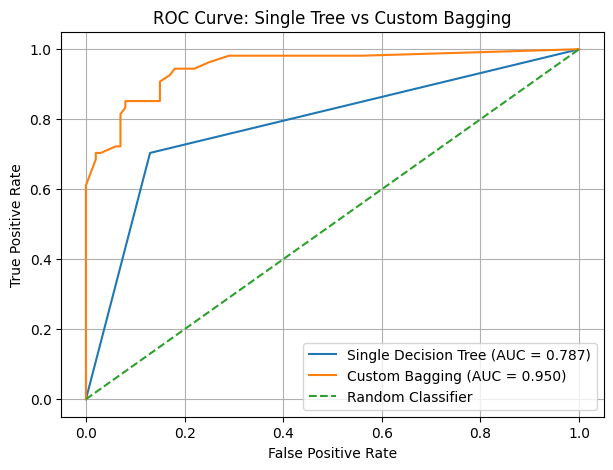

In [19]:
# TASK 9: ROC-AUC Analysis and Curve Visualization

# Probability prediction from single decision tree
single_probabilities = single_tree.predict_proba(X_test)[:, 1]

# Probability prediction from custom Bagging
all_probabilities = []

for tree in ensemble:
    probabilities = tree.predict_proba(X_test)[:, 1]
    all_probabilities.append(probabilities)

# Average probability from all 50 trees
bagging_probabilities = np.mean(
    all_probabilities,
    axis=0
)

# Calculate ROC curves
fpr_single, tpr_single, thresholds_single = roc_curve(
    y_test,
    single_probabilities
)

fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(
    y_test,
    bagging_probabilities
)

# Calculate AUC
auc_single = roc_auc_score(
    y_test,
    single_probabilities
)

auc_bagging = roc_auc_score(
    y_test,
    bagging_probabilities
)

# Print AUC
print("Single Decision Tree AUC:",
      round(auc_single, 4))

print("Custom Bagging AUC:",
      round(auc_bagging, 4))

# Plot ROC curves
plt.figure(figsize=(7, 5))

plt.plot(
    fpr_single,
    tpr_single,
    label=f"Single Decision Tree (AUC = {auc_single:.3f})"
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f"Custom Bagging (AUC = {auc_bagging:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Single Tree vs Custom Bagging")
plt.legend()
plt.grid()
plt.show()

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

Scikit-Learn Bagging Accuracy: 0.8831

Scikit-Learn Bagging Confusion Matrix:
[[91  9]
 [ 9 45]]

Final Model Comparison:
                  Model  Accuracy
0  Single Decision Tree  0.811688
1        Custom Bagging  0.889610
2  Scikit-Learn Bagging  0.883117


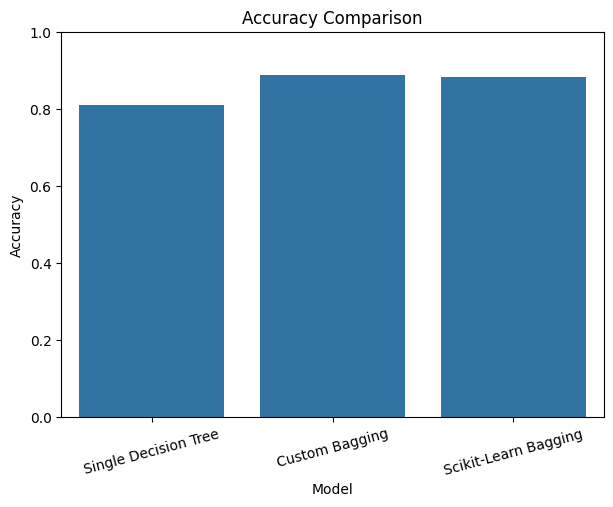

In [20]:
# TASK 10: Validation against Scikit-Learn BaggingClassifier

from sklearn.ensemble import BaggingClassifier

# Create built-in Bagging Classifier
sklearn_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None),
    n_estimators=50,
    random_state=42
)

# Train the model
sklearn_bagging.fit(X_train, y_train)

# Predict on test data
y_pred_sklearn = sklearn_bagging.predict(X_test)

# Calculate accuracy
sklearn_accuracy = accuracy_score(
    y_test,
    y_pred_sklearn
)

# Confusion matrix
sklearn_cm = confusion_matrix(
    y_test,
    y_pred_sklearn
)

# Display results
print("Scikit-Learn Bagging Accuracy:",
      round(sklearn_accuracy, 4))

print("\nScikit-Learn Bagging Confusion Matrix:")
print(sklearn_cm)

# Compare all models
final_comparison = pd.DataFrame({
    "Model": [
        "Single Decision Tree",
        "Custom Bagging",
        "Scikit-Learn Bagging"
    ],
    "Accuracy": [
        single_accuracy,
        bagging_accuracy,
        sklearn_accuracy
    ]
})

print("\nFinal Model Comparison:")
print(final_comparison)

# Plot accuracy comparison
plt.figure(figsize=(7, 5))

sns.barplot(
    data=final_comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?